number of bands: 26


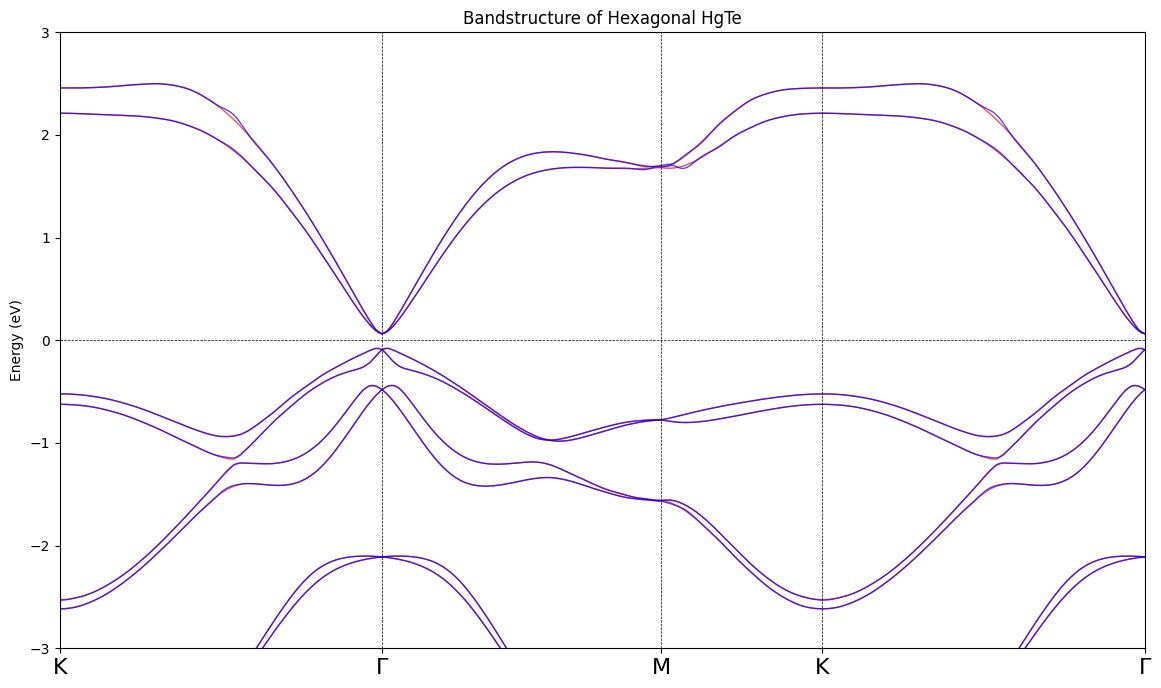

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data = np.loadtxt('bands.dat.gnu')
data_wan = np.loadtxt('wannier_band.dat')

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

k_wan = np.unique(data_wan[:, 0])
bands_wan = np.reshape(data_wan[:, 1], (-1, len(k_wan)))

fermi_level = -2.8663

k_wan = k_wan * (max(k) / max(k_wan))

high_symmetry_points = [0, 0.6667, 1.2440, 1.5774, 2.2440]  
high_symmetry_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

plt.figure(figsize=(14, 8))

for band in range(len(bands)):
    plt.plot(k, bands[band, :]-fermi_level, linewidth=1, alpha=0.7, color='red')
plt.xlim(min(k), max(k))

for band in range(len(bands_wan)):
    plt.plot(k_wan, bands_wan[band, :]-fermi_level, linewidth=1, alpha=0.7, color='blue')

#plt.plot(k, bands[19, :]-fermi_level, linewidth=1, alpha=0.7, color='blue')

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

print("number of bands:", len(bands))
plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of Hexagonal HgTe")
plt.ylabel("Energy (eV)")
plt.ylim(-3,3)
plt.show()

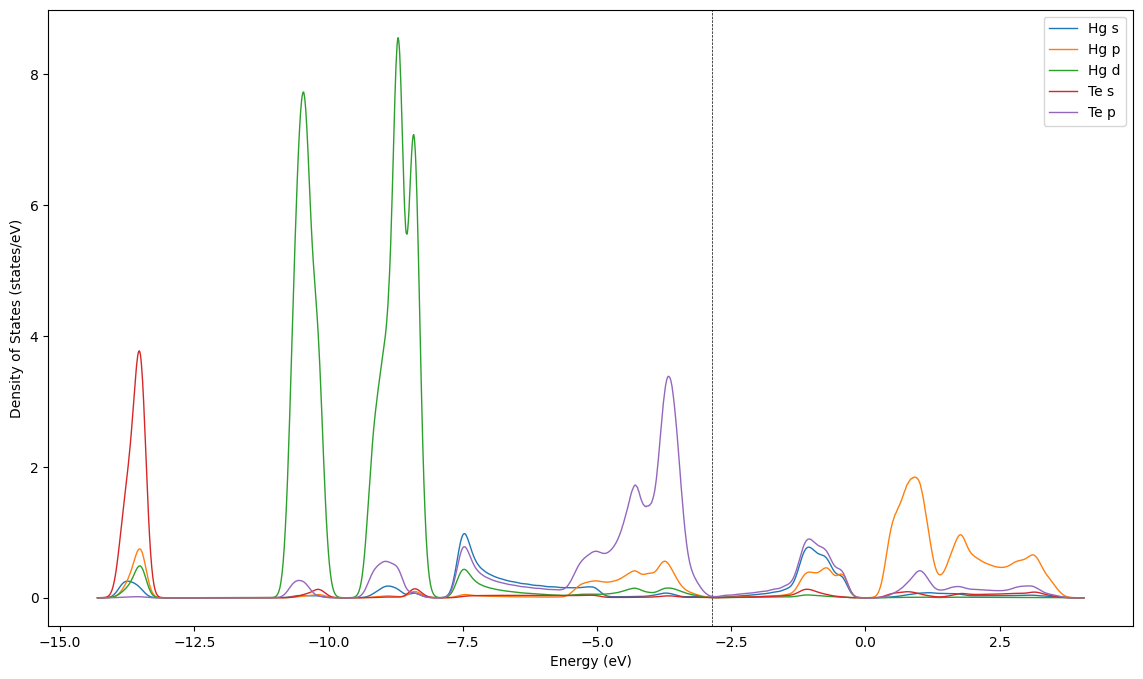

In [24]:
hg_s = np.loadtxt('atom_Hg_s.dat')
hg_p = np.loadtxt('atom_Hg_p.dat')
hg_d = np.loadtxt('atom_Hg_d.dat')
te_s = np.loadtxt('atom_Te_s.dat')
te_p = np.loadtxt('atom_Te_p.dat')

plt.figure(figsize=(14, 8))

plt.axvline(fermi_level, color='black', linestyle='--', lw=0.5)

plt.plot(hg_s[:, 0], hg_s[:, 1], label='Hg s', linewidth=1)
plt.plot(hg_p[:, 0], hg_p[:, 1], label='Hg p', linewidth=1)
plt.plot(hg_d[:, 0], hg_d[:, 1], label='Hg d', linewidth=1)
plt.plot(te_s[:, 0], te_s[:, 1], label='Te s', linewidth=1)
plt.plot(te_p[:, 0], te_p[:, 1], label='Te p', linewidth=1)
plt.xlabel('Energy (eV)')
plt.ylabel('Density of States (states/eV)')
plt.legend()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-11-19 11:32:26,927                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(8, 27, 2)                                  |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

ValueError: The given WCC are not degenerate Kramers pairs at the edges of the surface.

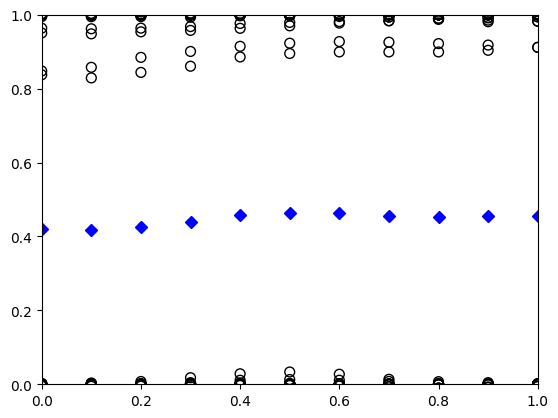

In [4]:
import z2pack, tbmodels
import matplotlib.pyplot as plt


model = tbmodels.Model.from_wannier_files(hr_file='wannier_hr.dat', wsvec_file='wannier_wsvec.dat',occ=20)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0])

z2pack.plot.wcc(result)
print("Z2 Invariant:", z2pack.invariant.z2(result))
plt.show()

number of bands: 26


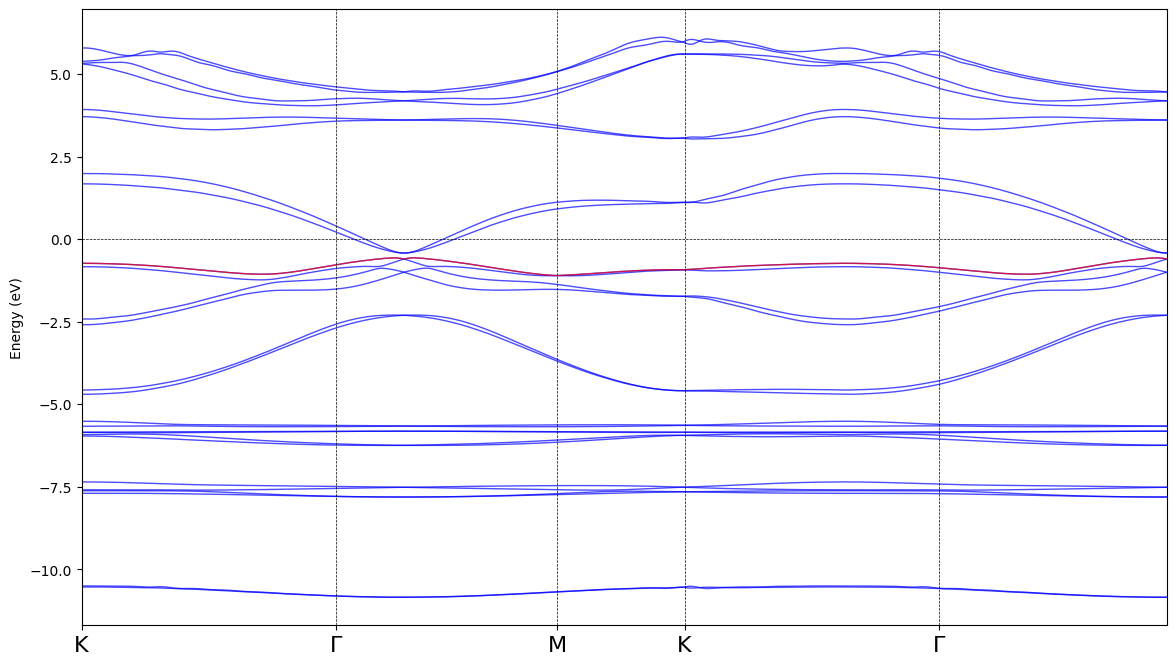

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data_wan = np.loadtxt('strained-wannier_band.dat')

k_wan = np.unique(data_wan[:, 0])
bands_wan = np.reshape(data_wan[:, 1], (-1, len(k_wan)))

fermi_level = -2.8663


high_symmetry_points = [0, 0.6667, 1.2440, 1.5774, 2.2440]  
high_symmetry_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

plt.figure(figsize=(14, 8))


plt.xlim(min(k_wan), max(k_wan))

for band in range(len(bands_wan)):
    plt.plot(k_wan, bands_wan[band, :]-fermi_level, linewidth=1, alpha=0.7, color='blue')

plt.plot(k_wan, bands_wan[17, :]-fermi_level, linewidth=1, alpha=0.7, color='red')

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

print("number of bands:", len(bands_wan))
plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel("Energy (eV)")
#plt.ylim(-3,3)
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-11-18 23:53:53,221                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

ValueError: The given WCC are not degenerate Kramers pairs at the edges of the surface.

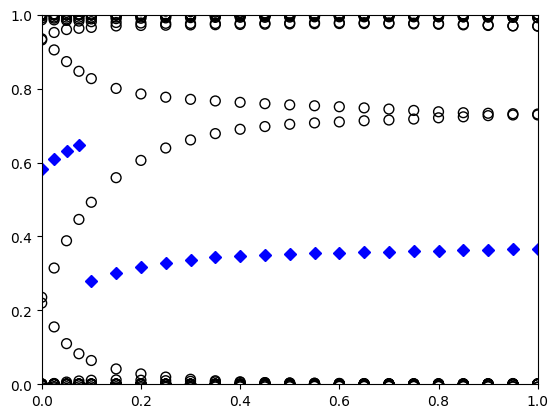

In [5]:
import z2pack, tbmodels


model = tbmodels.Model.from_wannier_files(hr_file='strained-wannier_hr.dat', wsvec_file='strained-wannier_wsvec.dat',occ=18)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\G'
<>:19: SyntaxWarning: invalid escape sequence '\G'
C:\Users\furka\AppData\Local\Temp\ipykernel_8800\4256794370.py:19: SyntaxWarning: invalid escape sequence '\G'
  plt.xticks(ticks=[0, 0.659, 1.319], labels=[r'$-\frac{\pi}{2}$', '$\Gamma$', r'$\frac{\pi}{2}$'])


([<matplotlib.axis.XTick at 0x29e83b26210>,
 [Text(0.0, 0, '$-\\frac{\\pi}{2}$'),
  Text(0.659, 0, '$\\Gamma$'),
  Text(1.319, 0, '$\\frac{\\pi}{2}$')])

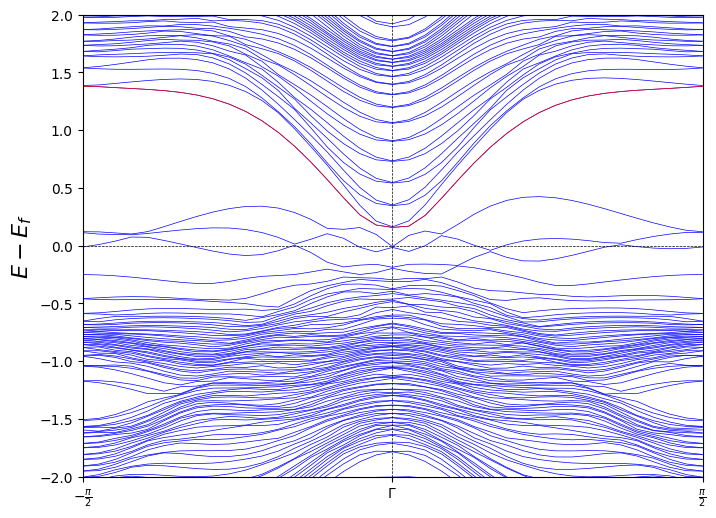

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt("edge-REFORMATTED_BAND.dat")

plt.figure(figsize=(8, 6))
for i in range(1,len(data_band[0,:])):
    plt.plot(data_band[:,0],data_band[:,i],lw=0.5,color='blue')

#plt.plot(data_band[:,0],data_band[:,363],lw=0.5,color='red')

plt.ylim(-2,2)

plt.xlim(min(data_band[:,0]), max(data_band[:,0]))
plt.ylabel(r'$E-E_f$', fontsize=16)
plt.axhline(0, ls='--', lw=0.5, color='black')
plt.axvline(0.659, ls='--', lw=0.5, color='black')
plt.axvline(1.319, ls='--', lw=0.5, color='black')       
plt.xticks(ticks=[0, 0.659, 1.319], labels=[r'$-\frac{\pi}{2}$', '$\Gamma$', r'$\frac{\pi}{2}$'])

<>:17: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\G'
C:\Users\furka\AppData\Local\Temp\ipykernel_8800\2332087281.py:17: SyntaxWarning: invalid escape sequence '\G'
  plt.xticks(ticks=[0, 0.659, 1.319], labels=[r'$-\frac{\pi}{2}$', '$\Gamma$', r'$\frac{\pi}{2}$'])


([<matplotlib.axis.XTick at 0x29e805a8050>,
 [Text(0.0, 0, '$-\\frac{\\pi}{2}$'),
  Text(0.659, 0, '$\\Gamma$'),
  Text(1.319, 0, '$\\frac{\\pi}{2}$')])

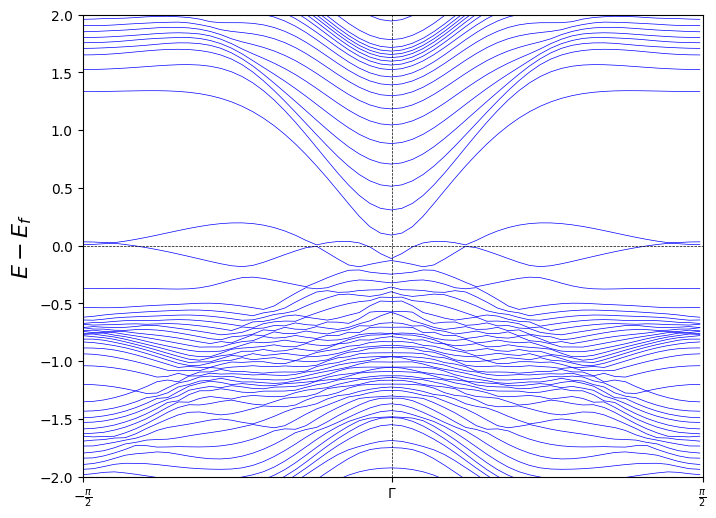

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt("wosoc-REFORMATTED_BAND.dat")

plt.figure(figsize=(8, 6))
for i in range(1,len(data_band[0,:])):
    plt.plot(data_band[:,0],data_band[:,i],lw=0.5,color='blue')
    
plt.ylim(-2,2)

plt.xlim(min(data_band[:,0]), max(data_band[:,0]))
plt.ylabel(r'$E-E_f$', fontsize=16)
plt.axhline(0, ls='--', lw=0.5, color='black')
plt.axvline(0.659, ls='--', lw=0.5, color='black')
plt.axvline(1.319, ls='--', lw=0.5, color='black')       
plt.xticks(ticks=[0, 0.659, 1.319], labels=[r'$-\frac{\pi}{2}$', '$\Gamma$', r'$\frac{\pi}{2}$'])

33


(-3.0, 3.0)

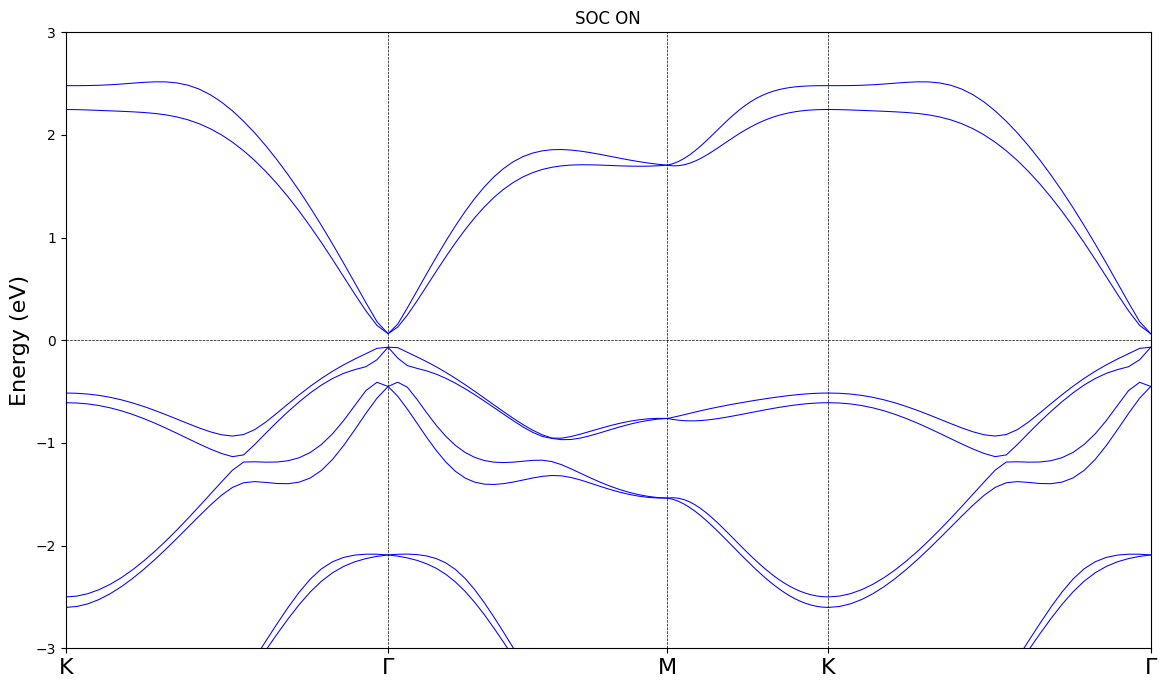

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('hgte-REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)
high_symmetry_points = [0,0.885,1.652,2.095,2.980]  
high_symmetry_labels = [ 'K', r'$\Gamma$', 'M','K', r'$\Gamma$']

plt.figure(figsize=(14, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue',lw=0.75)

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel('Energy (eV)', fontsize=16)
plt.title("SOC ON")
plt.xlim(min(k), max(k))
plt.ylim(-3,3)


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-02-25 22:32:58,891                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

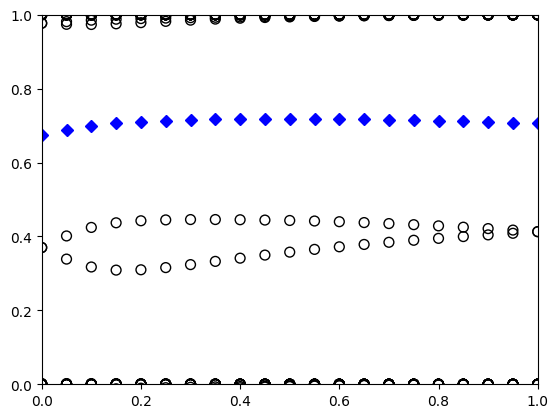

In [3]:
import z2pack, tbmodels

model = tbmodels.Model.from_wannier_files(hr_file='e05-wannier90_hr.dat', wsvec_file='e05-wannier90_wsvec.dat',occ=18)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

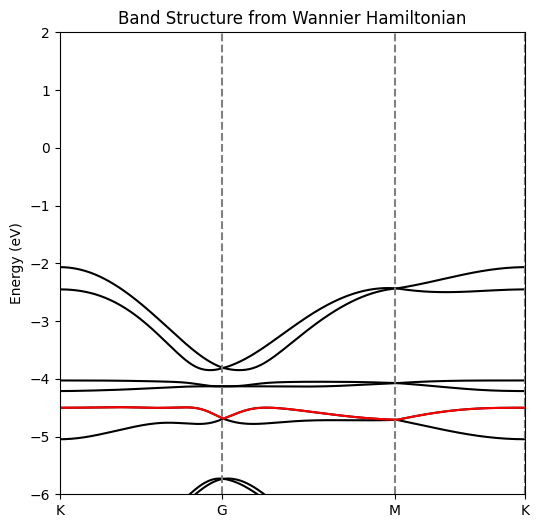

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def read_hamiltonian(path):

    """
    Read hopping matrix element from the wannier90 output file:wannier90_hr.dat
    wan_num: number of wannier functions
    wsc_num: number of wigner-sitez cells
    wsc_count: variables related to degeneracy
    """
    with open(path,"r") as f:
        lines=f.readlines()

    wan_num=int(lines[1]); wsc_num=int(lines[2])
    ski_row_num=int(np.ceil(wsc_num/15.0))      # skip row numbers
    wsc_count=[]
    for i in range(ski_row_num):
        wsc_count.extend(list(map(int,lines[i+3].split())))

    wsc_tot=np.zeros((wan_num**2*wsc_num,3))
    tem_tot=np.zeros((wan_num**2*wsc_num,2))
    for i in range(wan_num**2*wsc_num):
        wsc_tot[i,:]=list(map(int,lines[3+ski_row_num+i].split()[:3]))
        tem_tot[i,:]=list(map(float,lines[3+ski_row_num+i].split()[5:]))

    wsc_idx=wsc_tot[0:-1:wan_num**2,:]   # the translational vector between wigner-sitez cells
    hop_mat=np.reshape(tem_tot[:,0]+1j*tem_tot[:,1],[wan_num,wan_num,wsc_num],order='F')

    return hop_mat,wsc_idx,wsc_count,wan_num


def H_of_k(kvec, hop_mat, wsc_idx, wsc_count):
    """
    Construct H(k) from real-space hoppings.
    kvec: np.array([kx,ky,kz])
    hop_mat: (wan_num, wan_num, wsc_num)
    wsc_idx: (wsc_num, 3)
    wsc_count: list of degeneracies
    """
    wan_num = hop_mat.shape[0]
    Hk = np.zeros((wan_num, wan_num), dtype=complex)
    for R, count, H_R in zip(wsc_idx, wsc_count, hop_mat.transpose(2,0,1)):
        phase = np.exp(1j * np.dot(kvec, R))
        Hk += count * H_R * phase
    return Hk / sum(wsc_count)


# === Load the TB Hamiltonian from wannier_hr.dat ===
filename = "e15-wannier90_hr.dat"
hop_mat, wsc_idx, wsc_count, wan_num = read_hamiltonian(filename)

# === Define k-path ===
# Example for a square lattice Γ -> X -> M -> Γ
# Replace with the correct high-symmetry points of your system
k_points = {
    "G": [0.0, 0.0, 0.0],
    "K": [0.333, 0.3333, 0.0],
    "M": [0.5, 0.0, 0.0],
}
path = ["K", "G", "M", "K"]

# Interpolation (number of k-points between each segment)
nseg = 100

k_path = []
k_labels = []
distances = [0.0]

for i in range(len(path)-1):
    k_start = np.array(k_points[path[i]])
    k_end   = np.array(k_points[path[i+1]])
    for j in range(nseg):
        frac = j / nseg
        k_vec = (1-frac)*k_start + frac*k_end
        k_path.append(k_vec)
        if len(k_path) > 1:
            dk = np.linalg.norm(np.array(k_path[-1]) - np.array(k_path[-2]))
            distances.append(distances[-1] + dk)
    k_labels.append((distances[-1], path[i]))
k_labels.append((distances[-1], path[-1]))
k_path = np.array(k_path)

# === Build Hamiltonian H(k) and get eigenvalues ===
bands = []

for k in k_path:
    Hk = np.zeros((wan_num, wan_num), dtype=complex)
    for iR, R in enumerate(wsc_idx):
        phase = np.exp(1j * 2*np.pi * np.dot(k, R))
        Hk += hop_mat[:, :, iR] * phase * wsc_count[iR]
    eigvals = np.linalg.eigvalsh(Hk)
    bands.append(np.real(eigvals))

bands = np.array(bands)

# === Plot ===
plt.figure(figsize=(6,6))
for n in range(wan_num):
    plt.plot(distances, bands[:, n], 'k-')

plt.plot(distances, bands[:, 15], color='red')  # Highlight band 20
         
#plt.plot(distances, bands[:, 15], color='red')  # Highlight band 16

# High-symmetry lines
for x, label in k_labels:
    plt.axvline(x, color='gray', linestyle='--')

#fermi_level = -3.5109

#plt.axhline(fermi_level, color='red', linestyle='--', label='Fermi Level')

plt.xlim(0, max(distances))

plt.xticks([0] + np.array(k_labels)[:, 0].astype(float).tolist()[:-1] , np.array(k_labels)[:, 1].astype(str).tolist())

plt.ylim(-6, 2)
plt.ylabel("Energy (eV)")

plt.title("Band Structure from Wannier Hamiltonian")
plt.show()


Number of bands below Fermi level in DFT data: 18


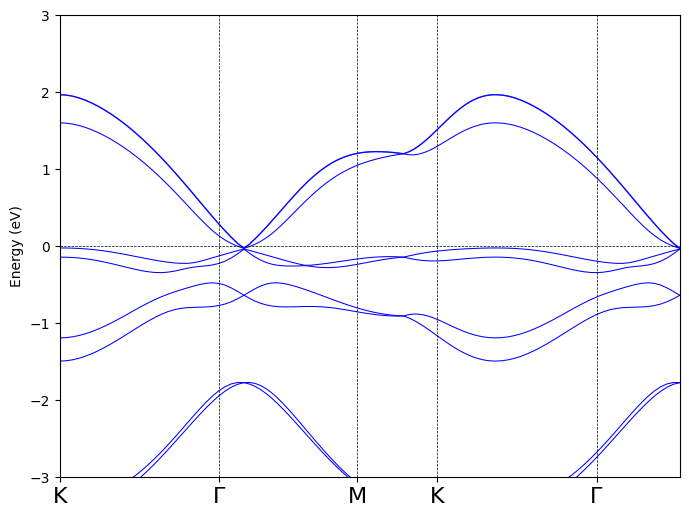

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data_dft = np.loadtxt('e15-REFORMATTED_BAND.dat')

k_dft = data_dft[:, 0]
band_dft = data_dft[:, 1:]


high_symmetry_points = [0, 0.6667, 1.2440, 1.5774, 2.2440]  
high_symmetry_labels = ['K',r'$\Gamma$','M', 'K', r'$\Gamma$',]

num_bands_below_fermi = np.sum(band_dft[0, :] < 0) 
print(f"Number of bands below Fermi level in DFT data: {num_bands_below_fermi}")

plt.figure(figsize=(8,6))

for i in range(band_dft.shape[1]):
    plt.plot(k_dft, band_dft[:, i], color='blue', linewidth=0.75, label='DFT' if i == 0 else "")

plt.xlim(min(k_dft), max(k_dft))

plt.plot(k, bands[19, :], linewidth=1, alpha=0.7, color='blue')

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel("Energy (eV)")
plt.ylim(-3,3)
plt.show()